# Waveforms

- different waveforms
- additive synthesis
- wavefolding
- frequency modulation

In [1]:
# the waveshape module is in the parent directory
import sys
sys.path.insert(0, '..')

# Explicit definitions
The easiest wave to produce with math is a sine wave. But other wave forms ([triangle](https://en.wikipedia.org/wiki/Triangle_wave), [sawtooth](https://en.wikipedia.org/wiki/Sawtooth_wave) and [square](https://en.wikipedia.org/wiki/Square_wave_(waveform))) can created with analytical functions, too.

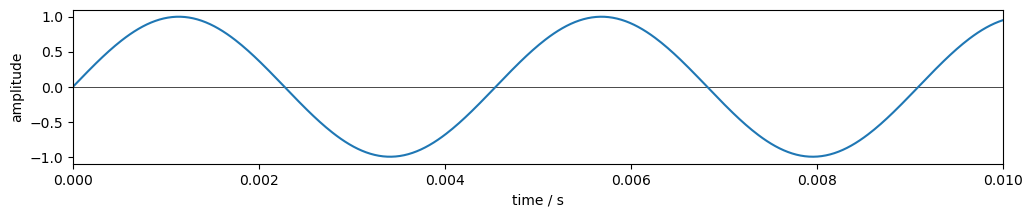

In [2]:
import wavestacker
import numpy as np
import matplotlib.pyplot as plt

def ax_firstsecond(ax, data):
    ax.axhline(0, lw=0.5, color='black')
    ax.plot(*data)
    ax.set_ylabel('amplitude')
    ax.set_xlabel('time / s')
    ax.set_xlim(0,1e-2)
    return ax
    
def sine(f, t): return np.sin(f * t * (np.pi * 2))
    
frequency = 220
t = np.linspace(0, 4, int(4*44100))
y = sine(frequency, t)
waves = {'sine':y}

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

buffer = wavestacker.Buffer(y)
buffer.play()

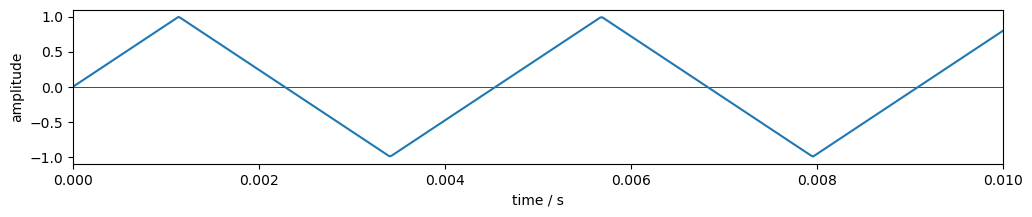

In [3]:
def triangle(f, t, phase=-0.25): return 2 * np.abs(2 * ((f * t + phase) % 1) - 1) -1
    
y = triangle(frequency, t)
waves['triangle'] = y
fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

buffer = wavestacker.Buffer(y)
buffer.play()

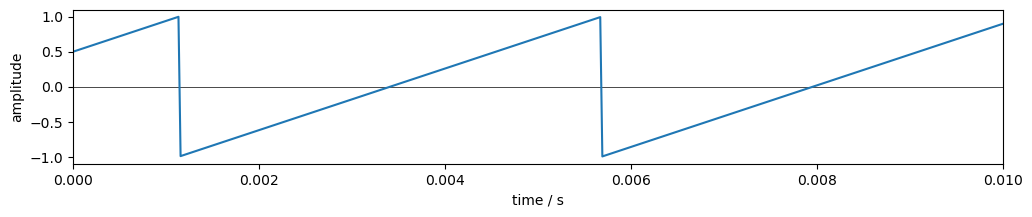

In [4]:
def sawtooth(f, t, phase=-0.25): return 2 * ((f * t + phase) % 1) - 1

y = sawtooth(frequency, t)
waves['sawtooth'] = y
fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

buffer = wavestacker.Buffer(y)
buffer.play()

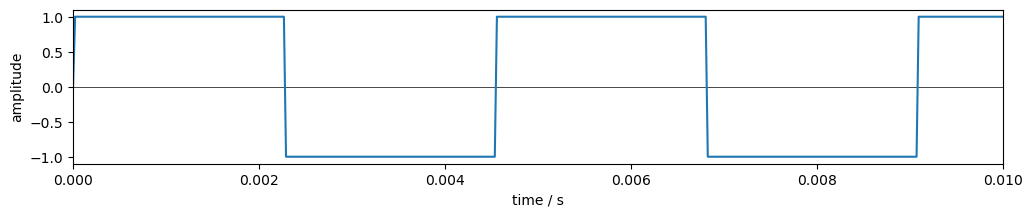

In [5]:
def square(f, t): return np.sign(np.sin(f * t * (np.pi * 2)))

y = square(frequency, t)
waves['square'] = y
fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

buffer = wavestacker.Buffer(y)
buffer.play()

# Additive synthesis

If we look at the spectrum of those waveforms, we can see how the more complex waves are composed of a sine and its harmonics. We can use this as a recipe to construct these waveforms from sine waves. 

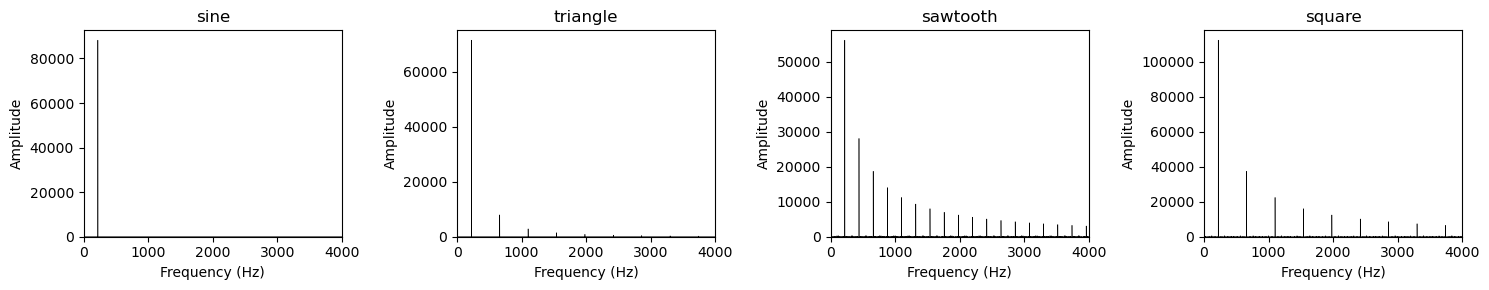

In [6]:
fig, axs = plt.subplots(1,len(waves), figsize=(15,3))

for ax, key in zip(axs, waves.keys()):
    wavestacker.plot_spectrum(waves[key], ax=ax)
    ax.set_xlim(0,4000)
    ax.set_title(key)

fig.tight_layout()

Because we only add a limited number of harmonics, the created waves are not perfectly in the target shape.

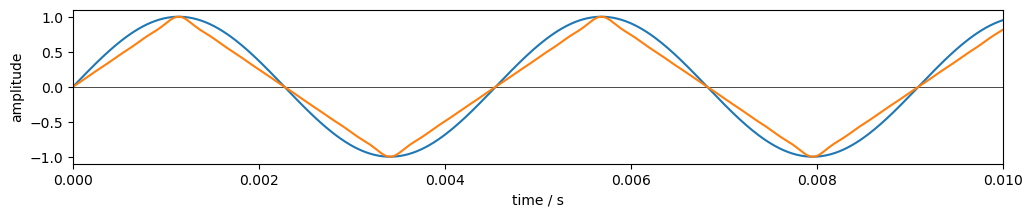

In [7]:
y = sine(frequency, t)

fig, ax = plt.subplots(figsize=(12, 2))
ax = ax_firstsecond(ax, (t, y))

# Add odd harmonics with decreasing amplitude and alternating phase
for n in range(3, 16, 2):  # Only odd harmonics
    y += ((-1)**((n-1)//2) / n**2) * sine(frequency * n, t)

y /= np.max(np.abs(y)) # normalise
ax.plot(t, y)

buffer = wavestacker.Buffer(y)
buffer.play()

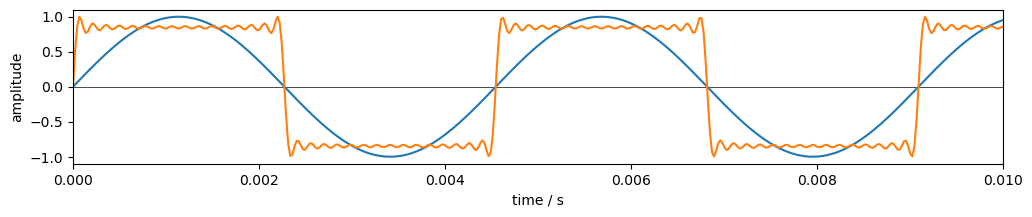

In [8]:
y = sine(frequency, t)

fig, ax = plt.subplots(figsize=(12, 2))
ax = ax_firstsecond(ax, (t, y))

# Add odd harmonics with decreasing amplitude
for n in range(3, 32, 2):  # Only odd harmonics
    y += (1 / n) * sine(frequency * n, t)
    # if n in [3,5,15,31, 63]: ax.plot(t, y, lw=0.4, color='tab:orange')
    
y /= np.max(np.abs(y))
ax.plot(t, y)

buffer = wavestacker.Buffer(y)
buffer.play()

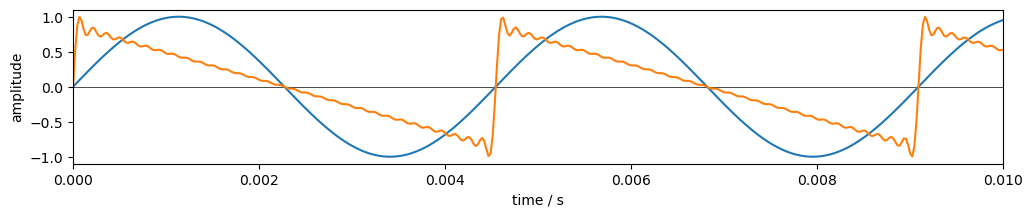

In [9]:
y = sine(frequency, t)
fig, ax = plt.subplots(figsize=(12, 2))
ax = ax_firstsecond(ax, (t, y))

# Add all harmonics with decreasing amplitude
for n in range(2, 32):  # All harmonics
    y += (1 / n) * sine(frequency * n, t)

y /= np.max(np.abs(y))
ax.plot(t, y)

buffer = wavestacker.Buffer(y)
buffer.play()

# Wavefolding

Another way to add harmonics to a wave is by *folding* it. In its simplest form any part of the wave above a certain threshold is just inverted. Normalising the wave ensures its amplitude is conserved and allows it to be folded again. More complex wave folding algorythms can be designed.

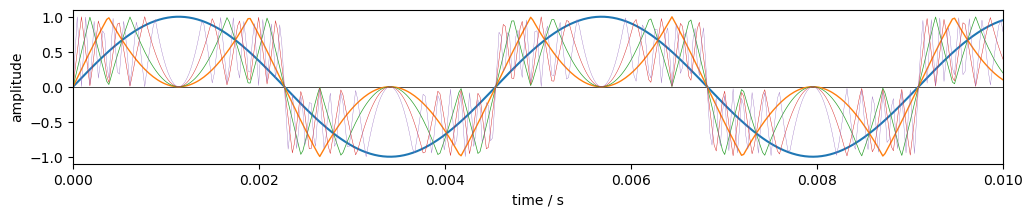

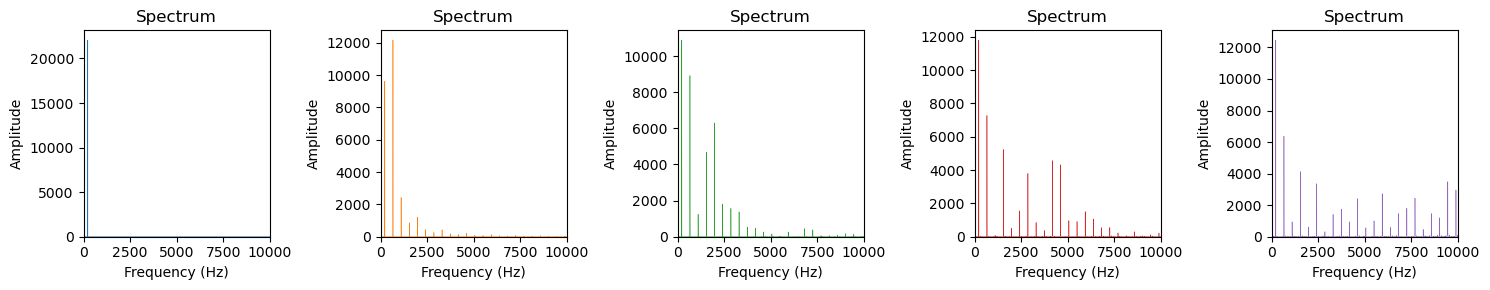

In [10]:
def wavefold(x, threshold=0.5):
    folded = np.where(x > threshold, 2 * threshold - x, x)
    folded = np.where(folded < -threshold, -2 * threshold - folded, folded)
    return folded

frequency = 220
sample_rate = 44100
t = np.linspace(0, 1, int(1*sample_rate))
y = sine(frequency, t)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

folds = [y]
for i in range(4):
    y = wavefold(y)
    y /= np.max(np.abs(y))
    folds.append(y)
    ax.plot(t, y, lw=1/(i+1))

fig, axs = plt.subplots(1,len(folds), figsize=(15,3))
for ax, f, color in zip(axs, folds, plt.rcParams['axes.prop_cycle'].by_key()['color']):
    wavestacker.plot_spectrum(f, ax=ax, color=color)
fig.tight_layout()

buffer = wavestacker.Buffer(np.concat(folds))
buffer.play()

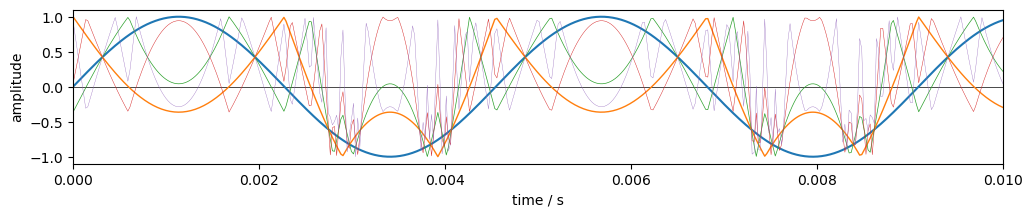

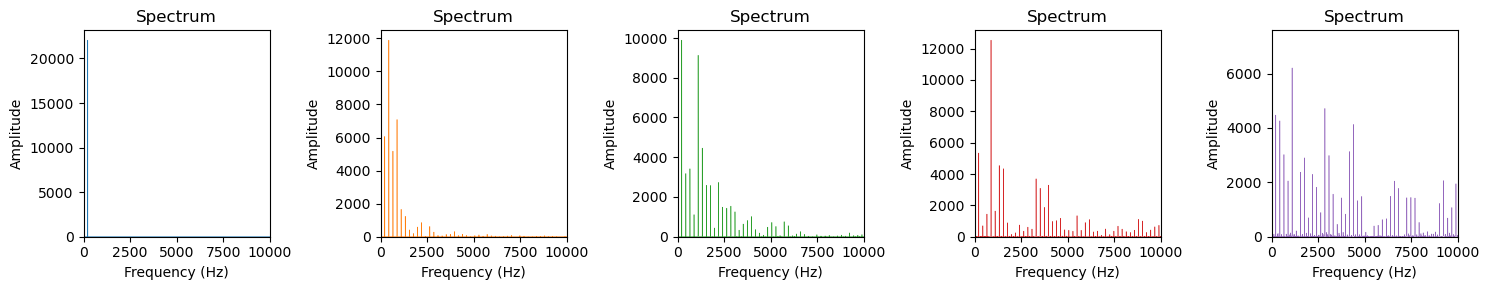

In [11]:
def wavefold(x, threshold=0.5):
    # Create a triangle wave for modulation
    triangle_wave = 2 * np.abs(2 * ((x / (2 * np.pi)) % 1) - 1) - 1
    modulated = x + triangle_wave * threshold
    # Fold the waveform based on the threshold
    folded = np.where(modulated > threshold, 2 * threshold - modulated, modulated)
    folded = np.where(folded < -threshold, -2 * threshold - folded, folded)
    return folded

y = sine(frequency, t)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

folds = [y]
for i in range(4):
    y = wavefold(y)
    y /= np.max(np.abs(y))
    folds.append(y)
    ax.plot(t, y, lw=1/(i+1))

fig, axs = plt.subplots(1,len(folds), figsize=(15,3))
for ax, f, color in zip(axs, folds, plt.rcParams['axes.prop_cycle'].by_key()['color']):
    wavestacker.plot_spectrum(f, ax=ax, color=color)
fig.tight_layout()

buffer = wavestacker.Buffer(np.concat(folds))
buffer.play()

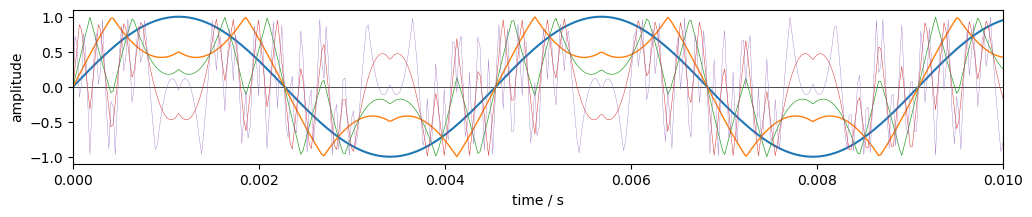

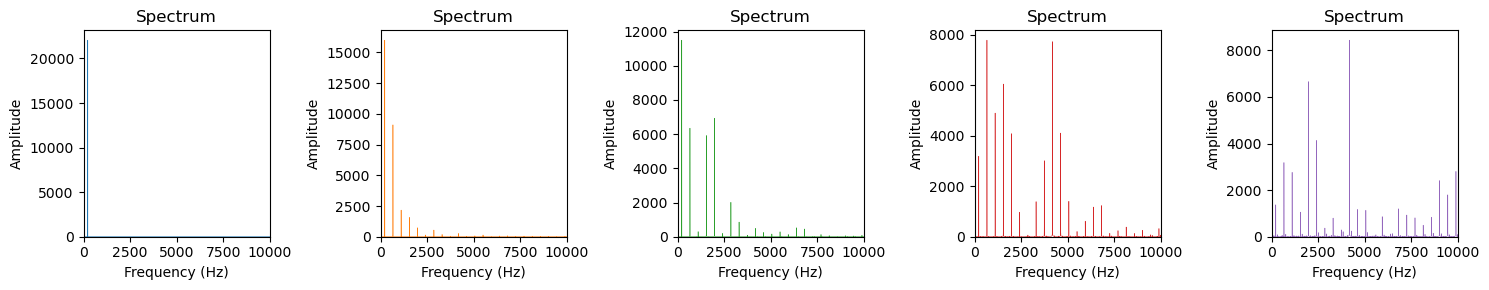

In [12]:
def wavefold(x, sample_rate=44100, triangle_freq=220, threshold=0.4):
    # Create a time array based on the sample rate
    t = np.arange(len(x)) / sample_rate
    # Create a triangle wave for modulation
    triangle_wave = 2 * np.abs(2 * ((triangle_freq * t + 0.25) % 1) - 1) - 1
    modulated = x + triangle_wave * threshold
    # Fold the waveform based on the threshold
    folded = np.where(modulated > threshold, 2 * threshold - modulated, modulated)
    folded = np.where(folded < -threshold, -2 * threshold - folded, folded)
    return folded

frequency = 220
sample_rate = 44100
t = np.linspace(0, 1, int(1*sample_rate))
y = sine(frequency, t)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, y))

folds = [y]
for i in range(4):
    y = wavefold(y)
    y /= np.max(np.abs(y))
    folds.append(y)
    ax.plot(t, y, lw=1/(i+1))

fig, axs = plt.subplots(1,len(folds), figsize=(15,3))
for ax, f, color in zip(axs, folds, plt.rcParams['axes.prop_cycle'].by_key()['color']):
    wavestacker.plot_spectrum(f, ax=ax, color=color)
fig.tight_layout()

buffer = wavestacker.Buffer(np.concat(folds))
buffer.play()

# Frequency modulation 

In frequencey modulation (FM) the frequency of a carrier signal is modulated with a modulating frequency.

In [29]:
frequency = 220
sample_rate = 44100
t = np.linspace(0, 1, int(1*sample_rate))
y = sine(frequency, t)

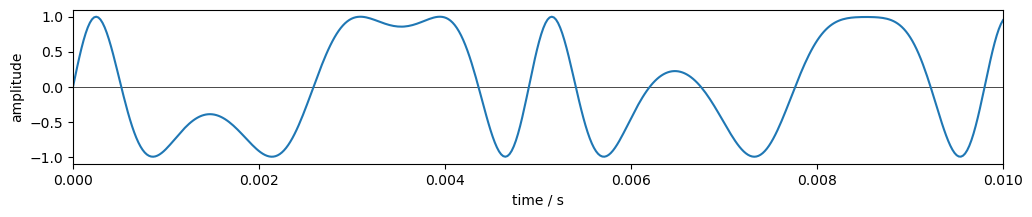

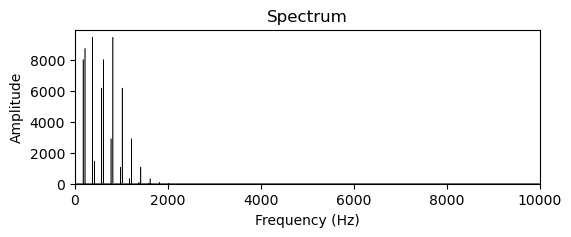

In [31]:
def generate_fm_wave(carrier_freq, modulating_freq, modulation_index, duration, sample_rate):
    time_array = np.linspace(0, duration, int(sample_rate * duration))
    # Modulating signal
    modulating_signal = np.sin(2 * np.pi * modulating_freq * time_array)
    # Frequency modulated signal
    fm_wave = np.sin(2 * np.pi * carrier_freq * time_array + modulation_index * modulating_signal)
    return fm_wave

# Example usage:
carrier_frequency = 220  # Carrier frequency in Hz
modulating_frequency = 200  # Modulating frequency in Hz
modulation_index = 4.0  # Modulation index
duration = 1.0  # Duration in seconds
sample_rate = 44100  # Sample rate in Hz

fm_signal = generate_fm_wave(carrier_frequency, modulating_frequency, modulation_index, duration, sample_rate)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, fm_signal))

wavestacker.plot_spectrum(fm_signal)

bf = wavestacker.Buffer(fm_signal)
bf.play()

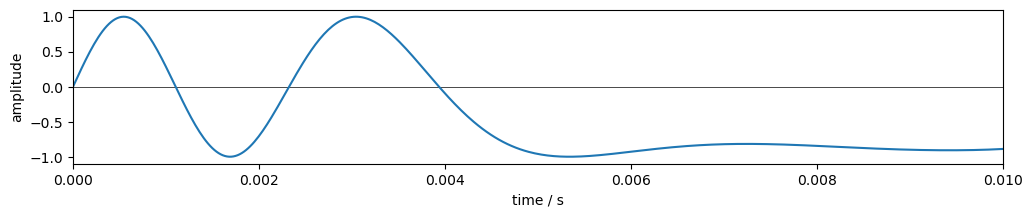

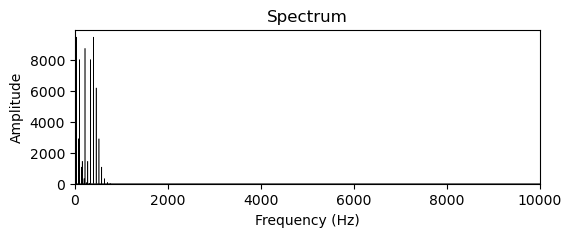

In [34]:
modulating_frequency = 60  # Modulating frequency in Hz
fm_signal = generate_fm_wave(carrier_frequency, modulating_frequency, modulation_index, duration, sample_rate)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, fm_signal))

wavestacker.plot_spectrum(fm_signal)

bf = wavestacker.Buffer(fm_signal)
bf.play()

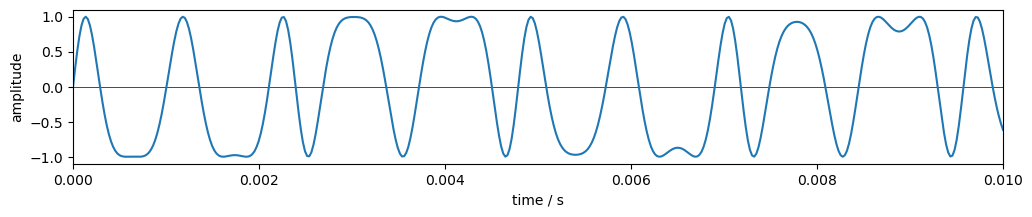

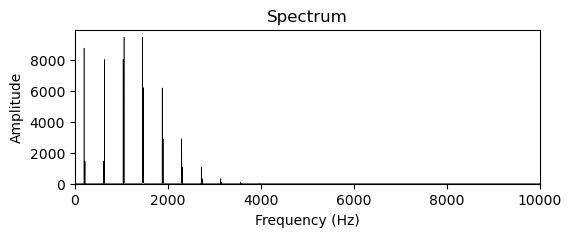

In [37]:
carrier_frequency = 200  # Carrier frequency in Hz
modulating_frequency = 420  # Modulating frequency in Hz

fm_signal = generate_fm_wave(carrier_frequency, modulating_frequency, modulation_index, duration, sample_rate)

fig, ax = plt.subplots(figsize=(12,2))
ax = ax_firstsecond(ax, (t, fm_signal))

wavestacker.plot_spectrum(fm_signal)

bf = wavestacker.Buffer(fm_signal)
bf.play()